# 浮體幾何條件計算

設定浮體之幾何條件為

$$
-b \le x \le b,\quad -l \le y \le l, \quad -d \le z \le d'
$$

其中 $b$ 為浮體半寬，$d$ 為吃水深，$d'$ 為出水深。

浮體之質量為 $m$, 密度為 $\rho_s$, 質量中心 (亦為轉動中心) 位於 $(0, 0, z_c)$。

## 慣性矩

In [4]:
# %%
# === Inertia Tensor of a Rectangular Solid Using SymPy ===
# Geometry: -b ≤ x ≤ b,  -l ≤ y ≤ l,  -d ≤ z ≤ d'
# Rotation center: (0, 0, z_c)

import sympy as sp
from sympy import latex, Eq, Symbol
from IPython.display import display, Math

# --- Define symbols ---
x, y, z = sp.symbols('x y z', real=True)
b, l, d, dp, rho_s, z_c = sp.symbols('b l d dp rho_s z_c', positive=True)

# --- Mass element ---
dm = rho_s  # density

# --- Integration limits ---
xlim = (-b, b)
ylim = (-l, l)
zlim = (-d, dp)

# --- Volume and total mass (for reference) ---
V = (2*b)*(2*l)*(d + dp)
m = rho_s * V

# --- Inertia about (0, 0, z_c) ---
Ixx_integrand = (y**2 + (z - z_c)**2) * dm
Iyy_integrand = (x**2 + (z - z_c)**2) * dm
Izz_integrand = (x**2 + y**2) * dm

Ixx = sp.integrate(Ixx_integrand, (x, *xlim), (y, *ylim), (z, *zlim))
Iyy = sp.integrate(Iyy_integrand, (x, *xlim), (y, *ylim), (z, *zlim))
Izz = sp.integrate(Izz_integrand, (x, *xlim), (y, *ylim), (z, *zlim))

# --- Simplify symbolic results ---
Ixx_s = sp.simplify(Ixx)
Iyy_s = sp.simplify(Iyy)
Izz_s = sp.simplify(Izz)

print("=== Symbolic results ===")
#sp.pprint(sp.Eq(sp.Symbol('Ixx'), Ixx_s))
#sp.pprint(sp.Eq(sp.Symbol('Iyy'), Iyy_s))
#sp.pprint(sp.Eq(sp.Symbol('Izz'), Izz_s))

# === Display symbolic results in LaTeX ===
display(Math(r"\textbf{Symbolic Results:}"))

display(Math(latex(Eq(Symbol('I_{xx}'), Ixx_s.simplify()))))
display(Math(latex(Eq(Symbol('I_{yy}'), Iyy_s.simplify()))))
display(Math(latex(Eq(Symbol('I_{zz}'), Izz_s.simplify()))))

=== Symbolic results ===


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Case 1: Chen and Hall (2022) 之基準案例

浮體之幾何條件為

- $b = 0.1~\mathrm{m}$
- $l = 0.1~\mathrm{m}$
- $d = 0.0786~\mathrm{m}$
- $d' = 0.0534~\mathrm{m}$

=== Floating Body Numerical Results ===
Water density rho_w = 1000.0 kg/m³
Computed solid density rho_s = 595.455 kg/m³
Geometric center z_c = -0.01260 m (measured from still water surface)
Mass m = 3.14400 kg
Ixx = 0.01505 kg·m²
Iyy = 0.01505 kg·m²
Izz = 0.02096 kg·m²


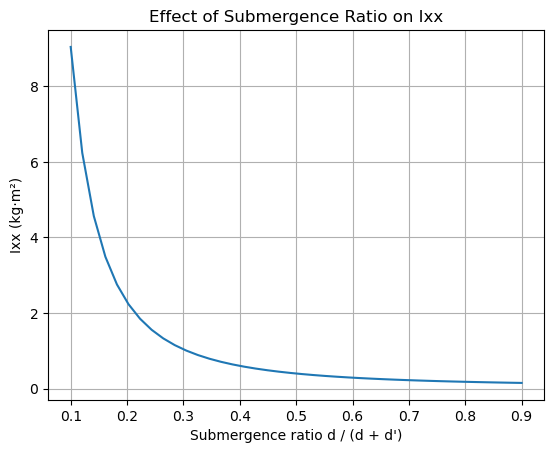

In [10]:
# %%
# === Substitute numerical values (floating body version) ===
# Floating rectangular body:
# -b ≤ x ≤ b,  -l ≤ y ≤ l,  -d ≤ z ≤ d'
# draft = d,  freeboard = d'

import numpy as np
import matplotlib.pyplot as plt

# Known parameters
rho_w = 1000.0     # water density [kg/m³]
b_val = 0.1        # half-length in x [m]
l_val = 0.1        # half-length in y [m]
d_val = 0.0786     # draft (below water) [m]
dp_val = 0.0534    # freeboard (above water) [m]

# --- Compute floating-body density and centroid location ---
rho_s_val = rho_w * d_val / (d_val + dp_val)      # uniform solid density
z_c_val = (dp_val - d_val) / 2                    # centroid (0 at still water surface)

# --- Create substitution dictionary ---
subs_dict = {
    b: b_val,
    l: l_val,
    d: d_val,
    dp: dp_val,
    rho_s: rho_s_val,
    z_c: z_c_val
}

# --- Evaluate inertia and mass ---
Ixx_val = float(Ixx_s.subs(subs_dict))
Iyy_val = float(Iyy_s.subs(subs_dict))
Izz_val = float(Izz_s.subs(subs_dict))
m_val = float(m.subs(subs_dict))

# --- Display results ---
print("=== Floating Body Numerical Results ===")
print(f"Water density rho_w = {rho_w:.1f} kg/m³")
print(f"Computed solid density rho_s = {rho_s_val:.3f} kg/m³")
print(f"Geometric center z_c = {z_c_val:.5f} m (measured from still water surface)")
print(f"Mass m = {m_val:,.5f} kg")
print(f"Ixx = {Ixx_val:,.5f} kg·m²")
print(f"Iyy = {Iyy_val:,.5f} kg·m²")
print(f"Izz = {Izz_val:,.5f} kg·m²")

# %%
# === Optional: visualize effect of draft/freeboard ratio ===
ratios = np.linspace(0.1, 0.9, 40)  # d / (d + d')
Ixx_list = []

for r in ratios:
    rho_s_tmp = rho_w * r
    d_tmp = 0.3
    dp_tmp = d_tmp * (1 - r) / r
    z_c_tmp = (dp_tmp - d_tmp) / 2
    val = float(Ixx_s.subs({b: b_val, l: l_val, d: d_tmp, dp: dp_tmp,
                            rho_s: rho_s_tmp, z_c: z_c_tmp}))
    Ixx_list.append(val)

plt.figure()
plt.plot(ratios, Ixx_list)
plt.xlabel("Submergence ratio d / (d + d')")
plt.ylabel("Ixx (kg·m²)")
plt.title("Effect of Submergence Ratio on Ixx")
plt.grid(True)
plt.show()


### Case 2: 基準案例加長寬度

浮體幾何條件為

- $b \simeq 3d = 0.236~\mathrm{m}$
- $l = 0.1~\mathrm{m}$
- $d = 0.0786~\mathrm{m}$
- $d' = 0.0534~\mathrm{m}$

In [11]:
# Known parameters
rho_w = 1000.0     # water density [kg/m³]
b_val = 0.236      # half-length in x [m]
l_val = 0.1        # half-length in y [m]
d_val = 0.0786     # draft (below water) [m]
dp_val = 0.0534    # freeboard (above water) [m]

# --- Compute floating-body density and centroid location ---
rho_s_val = rho_w * d_val / (d_val + dp_val)      # uniform solid density
z_c_val = (dp_val - d_val) / 2                    # centroid (0 at still water surface)

# --- Create substitution dictionary ---
subs_dict = {
    b: b_val,
    l: l_val,
    d: d_val,
    dp: dp_val,
    rho_s: rho_s_val,
    z_c: z_c_val
}

# --- Evaluate inertia and mass ---
Ixx_val = float(Ixx_s.subs(subs_dict))
Iyy_val = float(Iyy_s.subs(subs_dict))
Izz_val = float(Izz_s.subs(subs_dict))
m_val = float(m.subs(subs_dict))

# --- Display results ---
print("=== Floating Body Numerical Results ===")
print(f"Water density rho_w = {rho_w:.1f} kg/m³")
print(f"Computed solid density rho_s = {rho_s_val:.3f} kg/m³")
print(f"Geometric center z_c = {z_c_val:.5f} m (measured from still water surface)")
print(f"Mass m = {m_val:,.5f} kg")
print(f"Ixx = {Ixx_val:,.5f} kg·m²")
print(f"Iyy = {Iyy_val:,.5f} kg·m²")
print(f"Izz = {Izz_val:,.5f} kg·m²")

=== Floating Body Numerical Results ===
Water density rho_w = 1000.0 kg/m³
Computed solid density rho_s = 595.455 kg/m³
Geometric center z_c = -0.01260 m (measured from still water surface)
Mass m = 7.41984 kg
Ixx = 0.03551 kg·m²
Iyy = 0.14853 kg·m²
Izz = 0.16248 kg·m²
